<a href="https://colab.research.google.com/github/24691A05CY/CARDIO-VASCULAR-DISEASE-PREDICTION/blob/main/HDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/sample_data/CVD_cleaned.csv")

In [ ]:
df.head()

In [ ]:
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,119664.000000,119664.000000,119664.000000,119664.000000,119664.000000,119664.000000,119664.000000
mean,170.542711,83.132510,28.494185,5.211952,29.906797,15.239178,6.189756
std,10.655013,21.289321,6.522479,8.297636,24.849308,14.912422,8.499585
min,91.000000,25.400000,12.160000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.070000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,80.740000,27.410000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.620000,7.000000,30.000000,20.000000,8.000000
max,234.000000,293.020000,98.440000,30.000000,120.000000,120.000000,128.000000


In [ ]:
df.shape

(119665, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119665 entries, 0 to 119664
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                119665 non-null  object 
 1   Checkup                       119665 non-null  object 
 2   Exercise                      119664 non-null  object 
 3   Heart_Disease                 119664 non-null  object 
 4   Skin_Cancer                   119664 non-null  object 
 5   Other_Cancer                  119664 non-null  object 
 6   Depression                    119664 non-null  object 
 7   Diabetes                      119664 non-null  object 
 8   Arthritis                     119664 non-null  object 
 9   Sex                           119664 non-null  object 
 10  Age_Category                  119664 non-null  object 
 11  Height_(cm)                   119664 non-null  float64
 12  Weight_(kg)                   119664 non-nul

In [ ]:
df.isna().sum()

,0
General_Health,0
Checkup,0
Exercise,1
Heart_Disease,1
Skin_Cancer,1
Other_Cancer,1
Depression,1
Diabetes,1
Arthritis,1
Sex,1


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 13


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (119652, 19)


In [ ]:
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

In [ ]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

Target:
Heart_Disease


In [ ]:
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

In [ ]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

Target:
Heart_Disease


In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']

Numerical Columns:
['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


In [ ]:
print("Missing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

Missing values in X: 16
Missing values in y: 1


In [ ]:
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
X = df.drop("Heart_Disease", axis=1)
y = df["Heart_Disease"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (95721, 18)
X_test: (23931, 18)
y_train: (95721,)
y_test: (23931,)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy
data = df.copy()

# Encode all categorical columns
label_encoders = {}

for column in data.select_dtypes(include="object").columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column].astype(str))
    label_encoders[column] = le

# Separate features and target
X = data.drop("Heart_Disease", axis=1)
y = data["Heart_Disease"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data preprocessing completed successfully!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Data preprocessing completed successfully!
X_train: (95721, 18)
X_test: (23931, 18)


In [ ]:
print(X_train.dtypes)

General_Health                    int64
Checkup                           int64
Exercise                          int64
Skin_Cancer                       int64
Other_Cancer                      int64
Depression                        int64
Diabetes                          int64
Arthritis                         int64
Sex                               int64
Age_Category                      int64
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                   int64
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

predictions = lr.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Logistic Regression model trained successfully!")
print("Prediction completed successfully!")
print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

Logistic Regression model trained successfully!
Prediction completed successfully!
Accuracy: 0.919894697254607
Accuracy: 91.98946972546071 %


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Random Forest model trained successfully!")
print("Prediction completed successfully!")
print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

Random Forest model trained successfully!
Prediction completed successfully!
Accuracy: 0.919894697254607
Accuracy: 91.98946972546071 %


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

print("KNN model trained successfully!")
print("Prediction completed successfully!")

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

KNN model trained successfully!
Prediction completed successfully!
Accuracy: 0.9143370523588651
Accuracy: 91.4337052358865 %


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

predictions = dt.predict(X_test)

print("Decision Tree model trained successfully!")
print("Prediction completed successfully!")

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

Decision Tree model trained successfully!
Prediction completed successfully!
Accuracy: 0.862604989344365
Accuracy: 86.2604989344365 %


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC()

svm.fit(X_train, y_train)

predictions = svm.predict(X_test)

print("SVM model trained successfully!")
print("Prediction completed successfully!")

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

SVM model trained successfully!
Prediction completed successfully!
Accuracy: 0.9206050729179726
Accuracy: 92.06050729179725 %


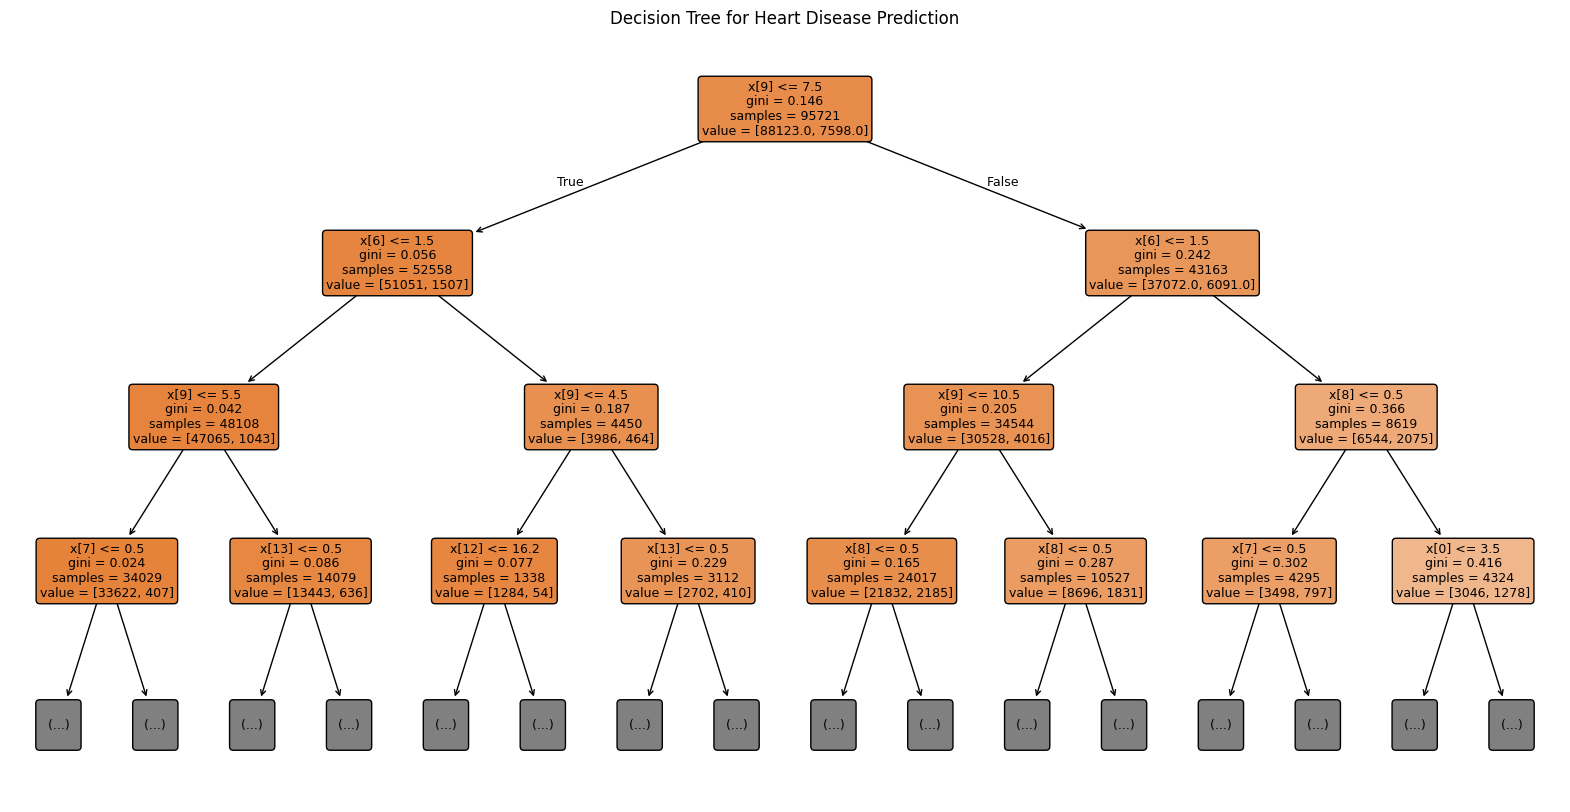

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Heart Disease Prediction")

plt.show()

In [ ]:
predictions = dt.predict(X_test)

print("Prediction completed successfully!")
print(predictions[:20])

Prediction completed successfully!
[0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0]


In [ ]:
print(label_encoders)

{'General_Health': LabelEncoder(), 'Checkup': LabelEncoder(), 'Exercise': LabelEncoder(), 'Heart_Disease': LabelEncoder(), 'Skin_Cancer': LabelEncoder(), 'Other_Cancer': LabelEncoder(), 'Depression': LabelEncoder(), 'Diabetes': LabelEncoder(), 'Arthritis': LabelEncoder(), 'Sex': LabelEncoder(), 'Age_Category': LabelEncoder(), 'Smoking_History': LabelEncoder()}


In [ ]:
new_patient = X.iloc[[0]]

prediction = dt.predict(new_patient)

print("Prediction completed successfully!")
print("Predicted Heart Disease:", prediction[0])

Prediction completed successfully!
Predicted Heart Disease: 0


In [ ]:
new_patient = X.iloc[[0]]

prediction = dt.predict(new_patient)[0]

if prediction == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


In [ ]:
from sklearn.metrics import accuracy_score

predictions = dt.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Decision Tree Accuracy:", accuracy * 100, "%")

Decision Tree Accuracy: 86.2604989344365 %


In [ ]:
from sklearn.metrics import accuracy_score

lr_predictions = lr.predict(X_test)
dt_predictions = dt.predict(X_test)
rf_predictions = rf.predict(X_test)
knn_predictions = knn.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_predictions) * 100, "%")

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_predictions) * 100, "%")

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predictions) * 100, "%")

print("KNN Accuracy:",
      accuracy_score(y_test, knn_predictions) * 100, "%")

Logistic Regression Accuracy: 91.98946972546071 %
Decision Tree Accuracy: 86.2604989344365 %
Random Forest Accuracy: 91.98946972546071 %
KNN Accuracy: 91.4337052358865 %


In [ ]:
import gradio as gr
import pandas as pd

def predict_heart_disease(*args):
    # Reconstruct input data based on the order of X.columns
    input_data_dict = {}
    for i, col_name in enumerate(X.columns):
        if col_name in categorical_cols:
            # Use the fitted LabelEncoder to transform the input string
            le = label_encoders[col_name]
            input_data_dict[col_name] = le.transform([args[i]])[0]
        else:
            input_data_dict[col_name] = args[i]

    # Create a DataFrame for prediction, ensuring column order matches training data
    input_df = pd.DataFrame([input_data_dict], columns=X.columns)

    results = {}
    models = {
        "Logistic Regression": lr,
        "Decision Tree": dt,
        "Random Forest": rf,
        "K-Nearest Neighbors": knn,
        "Support Vector Machine": svm
    }

    for name, model in models.items():
        prediction = model.predict(input_df)[0]
        # Map numerical prediction back to original labels if available, otherwise use 0/1
        # Assuming '0' maps to 'No Heart Disease' and '1' to 'Heart Disease'
        predicted_label = "Heart Disease" if prediction == 1 else "No Heart Disease"
        results[name] = predicted_label

    # Format the output for display
    output_message = "Heart Disease Prediction Results:\n"
    for name, result in results.items():
        output_message += f"{name}: {result}\n"
    return output_message

# Create Gradio input components dynamically
gradio_inputs = []
for col_name in X.columns:
    if col_name in categorical_cols:
        # Get original categories from the LabelEncoder classes
        choices = list(label_encoders[col_name].classes_)
        gradio_inputs.append(gr.Dropdown(choices=choices, label=col_name))
    elif col_name in numerical_cols:
        # Numerical columns
        gradio_inputs.append(gr.Number(label=col_name))
    else:
        # Fallback for any other unexpected column types
        gradio_inputs.append(gr.Textbox(label=col_name))

# Create and launch the Gradio interface
iface = gr.Interface(
    fn=predict_heart_disease,
    inputs=gradio_inputs,
    outputs=gr.Textbox(label="Prediction Output"),
    title="Heart Disease Prediction Interface",
    description="Enter patient details to predict the likelihood of Heart Disease using various models."
)

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://068b99c9e78b713576.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
